<a href="https://colab.research.google.com/github/JotaDC/TelecomX/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

##Leer y cargar datos en DataFrame

In [1]:
import requests
import pandas as pd
import numpy as np
url="https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"
response=requests.get(url)
datos=response.json()
df_base=pd.DataFrame(datos)
df_base.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


##Normalizacion

In [2]:
#Normalizacion de las columnas customer, phone, intenet y account
from pandas import json_normalize
df=json_normalize(datos)
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


## Diccionario de datos

- `customerID`: número de identificación único de cada cliente
- `Churn`: si el cliente dejó o no la empresa
- `gender`: género (masculino y femenino)
- `SeniorCitizen`: información sobre si un cliente tiene o no una edad igual o mayor a 65 años
- `Partner`: si el cliente tiene o no una pareja
- `Dependents`: si el cliente tiene o no dependientes
- `tenure`: meses de contrato del cliente
- `PhoneService`: suscripción al servicio telefónico
- `MultipleLines`: suscripción a más de una línea telefónica
- `InternetService`: suscripción a un proveedor de internet
- `OnlineSecurity`: suscripción adicional de seguridad en línea
- `OnlineBackup`: suscripción adicional de respaldo en línea
- `DeviceProtection`: suscripción adicional de protección del dispositivo
- `TechSupport`: suscripción adicional de soporte técnico, menor tiempo de espera
- `StreamingTV`: suscripción de televisión por cable
- `StreamingMovies`: suscripción de streaming de películas
- `Contract`: tipo de contrato
- `PaperlessBilling`: si el cliente prefiere recibir la factura en línea
- `PaymentMethod`: forma de pago
- `Charges.Monthly`: total de todos los servicios del cliente por mes
- `Charges.Total`: total gastado por el cliente

##Cambiar Nombre de las Columnas y Normalizarlas

In [3]:
#Cambiar nombres de las columnas
df.rename(columns={'customerID':'id_cliente','customer.gender':'genero','customer.SeniorCitizen':'mayor_de_65',
                   'customer.Partner':'pareja','customer.Dependents':'dependientes',
                   'customer.tenure':'meses_de_contrato','phone.PhoneService':'suscripcion_telefonia',
                   'phone.MultipleLines':'suscripcion_a_mas_de_una_linea_telefonica','internet.InternetService':'suscripcion_internet',
                   'internet.OnlineSecurity':'suscripcion_seguridad_en_linea','internet.OnlineBackup':'suscripcion_backup_en_linea',
                   'internet.DeviceProtection':'suscripcion_proteccion_de_dispositivos','internet.TechSupport':'suscripcion_soporte_tecnico',
                   'internet.StreamingTV':'suscripicion_streaming_tv','internet.StreamingMovies':'suscripcion_streaming_peliculas',
                   'account.Contract':'tipo_contrato','account.PaperlessBilling':'factura_online','account.PaymentMethod':'forma_de_pago',
                   'account.Charges.Monthly':'total_mensual','account.Charges.Total':'total_gastado','Churn':'se_fue'},inplace=True)

In [4]:
#Poner todas las columnas del df en minusculas
df.columns=df.columns.str.lower()

In [5]:
#quitar el punto que tiene las columnas y ponerle un guion bajo
df.columns=df.columns.str.replace('.','_')
df.head(3)

,id_cliente,se_fue,genero,mayor_de_65,pareja,dependientes,meses_de_contrato,suscripcion_telefonia,suscripcion_a_mas_de_una_linea_telefonica,suscripcion_internet,...,suscripcion_backup_en_linea,suscripcion_proteccion_de_dispositivos,suscripcion_soporte_tecnico,suscripicion_streaming_tv,suscripcion_streaming_peliculas,tipo_contrato,factura_online,forma_de_pago,total_mensual,total_gastado
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85


In [6]:
# Explorar las columnas del dataset y verificar sus tipos de datos.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   id_cliente                                 7267 non-null   object 
 1   se_fue                                     7267 non-null   object 
 2   genero                                     7267 non-null   object 
 3   mayor_de_65                                7267 non-null   int64  
 4   pareja                                     7267 non-null   object 
 5   dependientes                               7267 non-null   object 
 6   meses_de_contrato                          7267 non-null   int64  
 7   suscripcion_telefonia                      7267 non-null   object 
 8   suscripcion_a_mas_de_una_linea_telefonica  7267 non-null   object 
 9   suscripcion_internet                       7267 non-null   object 
 10  suscripcion_seguridad_en

In [7]:
df.dtypes

,0
id_cliente,object
se_fue,object
genero,object
mayor_de_65,int64
pareja,object
dependientes,object
meses_de_contrato,int64
suscripcion_telefonia,object
suscripcion_a_mas_de_una_linea_telefonica,object
suscripcion_internet,object


#🔧 Transformación

####Verificar si hay valores nulos

In [8]:
#Comprobación de incoherencias en los datos (valores ausentes, duplicados, errores de formato e inconsistencias en las categorías)
#Verifica si hay valores Nulos
print(f"Valores Nulos")
df.isnull().sum()


Valores Nulos


,0
id_cliente,0
se_fue,0
genero,0
mayor_de_65,0
pareja,0
dependientes,0
meses_de_contrato,0
suscripcion_telefonia,0
suscripcion_a_mas_de_una_linea_telefonica,0
suscripcion_internet,0


##Verificar si hay duplicados

In [9]:
#Verifica si hay de duplicados
print(f"Duplicados:{df.duplicated().sum()}")

Duplicados:0


##Verificar los valores unicos

In [10]:
#Verificar cantidad de valores unicos de cada columna
df.nunique()

,0
id_cliente,7267
se_fue,3
genero,2
mayor_de_65,2
pareja,2
dependientes,2
meses_de_contrato,73
suscripcion_telefonia,2
suscripcion_a_mas_de_una_linea_telefonica,3
suscripcion_internet,3


###Ver todos los valores unicos por columna

In [11]:
#Ver cuales son los valores unicos por columna
for col in df.columns:
   print(f"Valores unicos para la columna {col}:")
   print(df[col].unique())
   print("-"*80)

Valores unicos para la columna id_cliente:
['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
--------------------------------------------------------------------------------
Valores unicos para la columna se_fue:
['No' 'Yes' '']
--------------------------------------------------------------------------------
Valores unicos para la columna genero:
['Female' 'Male']
--------------------------------------------------------------------------------
Valores unicos para la columna mayor_de_65:
[0 1]
--------------------------------------------------------------------------------
Valores unicos para la columna pareja:
['Yes' 'No']
--------------------------------------------------------------------------------
Valores unicos para la columna dependientes:
['Yes' 'No']
--------------------------------------------------------------------------------
Valores unicos para la columna meses_de_contrato:
[ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 

##Valores en Blanco o String Vacios

In [12]:
#Ver valores en blanco o string vacios
valores_en_blanco_o_vacio = df.apply(lambda x: x.astype(str).str.strip() == '').sum()
print("\nValores en blanco o string vacios por columna:")
print(valores_en_blanco_o_vacio[valores_en_blanco_o_vacio > 0])


Valores en blanco o string vacios por columna:
se_fue           224
total_gastado     11
dtype: int64


In [13]:
###Eliminar Campos Vacios

In [14]:
# Eliminando las vacios de Churn
df = df[df['se_fue'].str.strip() != '']
print("Número de filas después de eliminar las vacías en 'se_fue':", len(df))

Número de filas después de eliminar las vacías en 'se_fue': 7043


In [15]:
# Eliminando las vacios de account_charges_total
df = df[df['total_gastado'].str.strip() != '']
print("Número de filas después de eliminar las vacías en 'total_gastado':", len(df))

Número de filas después de eliminar las vacías en 'total_gastado': 7032


In [16]:
##Convertir total_gastado a tipo de dato Numerico

In [17]:
#Convertir account_charges_total a tipo de dato numerico
df["total_gastado"]=pd.to_numeric(df["total_gastado"],errors="coerce")
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   id_cliente                                 7032 non-null   object 
 1   se_fue                                     7032 non-null   object 
 2   genero                                     7032 non-null   object 
 3   mayor_de_65                                7032 non-null   int64  
 4   pareja                                     7032 non-null   object 
 5   dependientes                               7032 non-null   object 
 6   meses_de_contrato                          7032 non-null   int64  
 7   suscripcion_telefonia                      7032 non-null   object 
 8   suscripcion_a_mas_de_una_linea_telefonica  7032 non-null   object 
 9   suscripcion_internet                       7032 non-null   object 
 10  suscripcion_seguridad_en_line

In [18]:
#Convertir mayor_de_60 a string
df["mayor_de_65"]=df["mayor_de_65"].astype(str)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   id_cliente                                 7032 non-null   object 
 1   se_fue                                     7032 non-null   object 
 2   genero                                     7032 non-null   object 
 3   mayor_de_65                                7032 non-null   object 
 4   pareja                                     7032 non-null   object 
 5   dependientes                               7032 non-null   object 
 6   meses_de_contrato                          7032 non-null   int64  
 7   suscripcion_telefonia                      7032 non-null   object 
 8   suscripcion_a_mas_de_una_linea_telefonica  7032 non-null   object 
 9   suscripcion_internet                       7032 non-null   object 
 10  suscripcion_seguridad_en_line

In [19]:
#Convertir campos binarios Yes a 1 y No a 0
#col_binarias=['se_fue','pareja','dependientes','suscripcion_telefonia','suscripcion_internet','suscripcion_proteccion_de_dispositivos','suscripcion_seguridad_en_linea','suscripcion_backup_en_linea','suscripcion_soporte_tecnico','suscripicion_streaming_tv','suscripcion_streaming_peliculas','factura_online']
#for col in col_binarias:
#    df.loc[:,col]=df.loc[:,col].apply(lambda x: 1 if x=='Yes' else 0)
#df.sample(5)


###Crear Columna cuentas_diarias

In [20]:
#Crear columna cuentas_diarias
df["cuentas_diarias"]=df["total_mensual"]/30
#hacer un sample de las columnas total_mensal y cuentas_diarias
df.sample(5)[['total_mensual','cuentas_diarias']]


,total_mensual,cuentas_diarias
5447,86.10,2.870000
1044,59.50,1.983333
5486,110.50,3.683333
3988,103.30,3.443333
183,60.55,2.018333


#📊 Carga y análisis

###Estadisticos de variables numericas

In [21]:
#análisis descriptivo de los datos, calculando métricas como media, mediana, desviación estándar
#y otras medidas que ayuden a comprender mejor la distribución y el comportamiento de los clientes.
df.describe()

,meses_de_contrato,total_mensual,total_gastado,cuentas_diarias
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441,2.159940
std,24.545260,30.085974,2266.771362,1.002866
min,1.000000,18.250000,18.800000,0.608333
25%,9.000000,35.587500,401.450000,1.186250
50%,29.000000,70.350000,1397.475000,2.345000
75%,55.000000,89.862500,3794.737500,2.995417
max,72.000000,118.750000,8684.800000,3.958333


###Estadisticos de variables Categoricas

In [22]:
#estadistica de variables categoricas
df.describe(include='object')

,id_cliente,se_fue,genero,mayor_de_65,pareja,dependientes,suscripcion_telefonia,suscripcion_a_mas_de_una_linea_telefonica,suscripcion_internet,suscripcion_seguridad_en_linea,suscripcion_backup_en_linea,suscripcion_proteccion_de_dispositivos,suscripcion_soporte_tecnico,suscripicion_streaming_tv,suscripcion_streaming_peliculas,tipo_contrato,factura_online,forma_de_pago
count,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032
unique,7032,2,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
top,9995-HOTOH,No,Male,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check
freq,1,5163,3549,5890,3639,4933,6352,3385,3096,3497,3087,3094,3472,2809,2781,3875,4168,2365


###Distribucion de cada columna con menos de 5 datos

In [23]:
#distribucion de cada columna con menos de 5 datos
for col in df.columns:
    print(f"Distribución de {col}:")
    if df[col].value_counts().shape[0] <= 5:
      print(df[col].value_counts())
      print("-"*80)

Distribución de id_cliente:
Distribución de se_fue:
se_fue
No     5163
Yes    1869
Name: count, dtype: int64
--------------------------------------------------------------------------------
Distribución de genero:
genero
Male      3549
Female    3483
Name: count, dtype: int64
--------------------------------------------------------------------------------
Distribución de mayor_de_65:
mayor_de_65
0    5890
1    1142
Name: count, dtype: int64
--------------------------------------------------------------------------------
Distribución de pareja:
pareja
No     3639
Yes    3393
Name: count, dtype: int64
--------------------------------------------------------------------------------
Distribución de dependientes:
dependientes
No     4933
Yes    2099
Name: count, dtype: int64
--------------------------------------------------------------------------------
Distribución de meses_de_contrato:
Distribución de suscripcion_telefonia:
suscripcion_telefonia
Yes    6352
No      680
Name: count, dtype

###Graficas

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

#!pip install -U plotly kaleido
import kaleido
import plotly.express as px

In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
df.columns

Index(['id_cliente', 'se_fue', 'genero', 'mayor_de_65', 'pareja',
       'dependientes', 'meses_de_contrato', 'suscripcion_telefonia',
       'suscripcion_a_mas_de_una_linea_telefonica', 'suscripcion_internet',
       'suscripcion_seguridad_en_linea', 'suscripcion_backup_en_linea',
       'suscripcion_proteccion_de_dispositivos', 'suscripcion_soporte_tecnico',
       'suscripicion_streaming_tv', 'suscripcion_streaming_peliculas',
       'tipo_contrato', 'factura_online', 'forma_de_pago', 'total_mensual',
       'total_gastado', 'cuentas_diarias'],
      dtype='object')

####Distribución de bajas

In [27]:
#Grafico de Abandono
print(df['se_fue'].value_counts())
#df temporal con los datos mapeados para visualizacion
#df_temp=df.assign(
#        Abandono=df['se_fue'].map({1: 'Sí', 0: 'No'})
#    )
#pie
conteo = df['se_fue'].value_counts().reset_index()
conteo.columns = ['se_fue', 'cantidad']
conteo
fig = px.pie(conteo, names='se_fue', values='cantidad', title='Distribución de bajas (Yes/No)')

fig.write_html('/content/abandono.html')
fig.show()

se_fue
No     5163
Yes    1869
Name: count, dtype: int64


####Distribución de Abandono segun el Genero

In [28]:
import plotly.express as px

#df temporal con los datos mapeados para visualizacion
#df_temp=df.assign(
#        Abandono=df['se_fue'].map({1: 'Sí', 0: 'No'}),
#        Genero=df['genero'].map({'Female': 'Femenino', 'Male': 'Masculino'})
#    )

df_temp=df.assign(
        Abandono=df['se_fue'],
        Genero=df['genero']
    )


#Calcular conteo y porcentaje manualmente
df_group = (
    df_temp.groupby(['Genero', 'Abandono'])
    .size()
    .reset_index(name='conteo')
)




# Agregar porcentaje
total_por_genero = df_group.groupby('Genero')['conteo'].transform('sum')
df_group['porcentaje'] = (df_group['conteo'] / total_por_genero * 100).round(1)

# Texto combinado
df_group['texto'] = df_group['conteo'].astype(str) + " (" + df_group['porcentaje'].astype(str) + "%)"
print(df_group)

# Crear histograma con datos agregados
fig = px.bar(
    df_group,
    x='Genero',
    y='conteo',
    color='Abandono',
    text='texto',
    barmode='group',
    labels={'conteo': 'Cantidad', 'Genero': 'Género'}
)

fig.update_layout(title="Distribución de Género vs Abandono (Conteo y %)", yaxis_title="Cantidad")
fig.write_html('/content/genero.html')
fig.show()



   Genero Abandono  conteo  porcentaje         texto
0  Female       No    2544        73.0  2544 (73.0%)
1  Female      Yes     939        27.0   939 (27.0%)
2    Male       No    2619        73.8  2619 (73.8%)
3    Male      Yes     930        26.2   930 (26.2%)


####Distribución de Abandono según si tiene pareja

In [29]:
#Grafico Abandono segun si tiene pareja o no
#df temporal con los datos mapeados para visualizacion
#df_temp=df.assign(
#        Abandono=df['se_fue'].map({1: 'Sí', 0: 'No'}),
#        Pareja=df['pareja'].map({1: 'En Pareja', 0: 'Sin Pareja'})
#    )

df_temp=df.assign(
        Abandono=df['se_fue'],
        Pareja=df['pareja']
    )
# Calcular conteo y porcentaje manualmente
df_group = (
    df_temp.groupby(['Pareja', 'Abandono'])
    .size()
    .reset_index(name='conteo')
)
df_group


#Grafico agrupando se_fue con pareja
print(df.groupby(['pareja','se_fue']).size().reset_index(name='conteo'))

# Agregar porcentaje
total = df_group.groupby('Pareja')['conteo'].transform('sum')
df_group['porcentaje'] = (df_group['conteo'] / total * 100).round(1)

# Texto combinado
df_group['texto'] = df_group['conteo'].astype(str) + " (" + df_group['porcentaje'].astype(str) + "%)"
print(df_group)

# Crear histograma con datos agregados
fig = px.bar(
    df_group,
    x='Pareja',
    y='conteo',
    color='Abandono',
    text='texto',
    barmode='group',
    labels={'conteo': 'Cantidad', 'pareja': 'Pareja'}
)

fig.update_layout(title="Abandono segun si esta en Pareja (Conteo y %)", yaxis_title="Cantidad")
fig.write_html('/content/pareja.html')
fig.show()


  pareja se_fue  conteo
0     No     No    2439
1     No    Yes    1200
2    Yes     No    2724
3    Yes    Yes     669
  Pareja Abandono  conteo  porcentaje         texto
0     No       No    2439        67.0  2439 (67.0%)
1     No      Yes    1200        33.0  1200 (33.0%)
2    Yes       No    2724        80.3  2724 (80.3%)
3    Yes      Yes     669        19.7   669 (19.7%)


####Distribución de Abandono según si es mayor de 65 años

In [30]:
#Grafico Abandono segun si es mayor de 65 años
#df temporal con los datos mapeados para visualizacion
#df_temp=df.assign(
#        Abandono=df['se_fue'].map({1: 'Sí', 0: 'No'}),
#        Mayor=df['mayor_de_65'].map({'1': 'Sí', '0': 'No'})
#    )

df_temp=df.assign(
        Abandono=df['se_fue'],
        Mayor=df['mayor_de_65'].map({'1': 'Mayor de 65', '0': 'Menor de 65'})
    )

# Calcular conteo y porcentaje manualmente
df_group = (
    df_temp.groupby(['Mayor', 'Abandono'])
    .size()
    .reset_index(name='conteo')
)



#Grafico agrupando se_fue con pareja
print(df.groupby(['mayor_de_65','se_fue']).size().reset_index(name='conteo'))

# Agregar porcentaje
total = df_group.groupby('Mayor')['conteo'].transform('sum')
df_group['porcentaje'] = (df_group['conteo'] / total * 100).round(1)

# Texto combinado
df_group['texto'] = df_group['conteo'].astype(str) + " (" + df_group['porcentaje'].astype(str) + "%)"
print(df_group)

# Crear histograma con datos agregados
fig = px.bar(
    df_group,
    x='Mayor',
    y='conteo',
    color='Abandono',
    text='texto',
    barmode='group',
    labels={'conteo': 'Cantidad', 'pareja': 'Pareja'}
)

fig.update_layout(title="Abandono según si es mayor de 65 años", yaxis_title="Cantidad")
fig.write_html('/content/mayor_65.html')
fig.show()



  mayor_de_65 se_fue  conteo
0           0     No    4497
1           0    Yes    1393
2           1     No     666
3           1    Yes     476
         Mayor Abandono  conteo  porcentaje         texto
0  Mayor de 65       No     666        58.3   666 (58.3%)
1  Mayor de 65      Yes     476        41.7   476 (41.7%)
2  Menor de 65       No    4497        76.3  4497 (76.3%)
3  Menor de 65      Yes    1393        23.7  1393 (23.7%)


####Distribución de Abandono según Dependientes

In [31]:
#Grafico Abandono segun Dependientes
#df temporal con los datos mapeados para visualizacion
#df_temp=df.assign(
#        Abandono=df['se_fue'].map({1: 'Sí', 0: 'No'}),
#        Dependientes=df['dependientes'].map({1: 'Sí', 0: 'No'})
#    )
df_temp=df.assign(
        Abandono=df['se_fue'],
        Dependientes=df['dependientes']
    )
# Calcular conteo y porcentaje manualmente
df_group = (
    df_temp.groupby(['Dependientes', 'Abandono'])
    .size()
    .reset_index(name='conteo')
)



#Grafico agrupando se_fue con pareja
print(df.groupby(['dependientes','se_fue']).size().reset_index(name='conteo'))

# Agregar porcentaje
total = df_group.groupby('Dependientes')['conteo'].transform('sum')
df_group['porcentaje'] = (df_group['conteo'] / total * 100).round(1)

# Texto combinado
df_group['texto'] = df_group['conteo'].astype(str) + " (" + df_group['porcentaje'].astype(str) + "%)"
print(df_group)

# Crear histograma con datos agregados
fig = px.bar(
    df_group,
    x='Dependientes',
    y='conteo',
    color='Abandono',
    text='texto',
    barmode='group',
    labels={'conteo': 'Cantidad', 'Dependientes': 'Dependientes'}
)

fig.update_layout(title="Abandono segun si tiene Dependientes (Conteo y %)", yaxis_title="Cantidad")
fig.write_html('/content/dependientes.html')
fig.show()

  dependientes se_fue  conteo
0           No     No    3390
1           No    Yes    1543
2          Yes     No    1773
3          Yes    Yes     326
  Dependientes Abandono  conteo  porcentaje         texto
0           No       No    3390        68.7  3390 (68.7%)
1           No      Yes    1543        31.3  1543 (31.3%)
2          Yes       No    1773        84.5  1773 (84.5%)
3          Yes      Yes     326        15.5   326 (15.5%)


####Distribución Abandono según los meses de contrato

In [32]:
#Grafico Abandono según los meses de contrato
#df temporal con los datos mapeados para visualizacion
#df_temp=df.assign(
#        Abandono=df['se_fue'].map({1: 'Sí', 0: 'No'})
#    )

df_temp=df.assign(
        Abandono=df['se_fue']
    )

# Calcular conteo y porcentaje manualmente
df_group = (
    df_temp.groupby(['meses_de_contrato', 'Abandono'])
    .size()
    .reset_index(name='conteo')
)

#Grafico agrupando se_fue con pareja
print(df.groupby(['meses_de_contrato','se_fue']).size().reset_index(name='conteo'))

# Agregar porcentaje
total = df_group.groupby('meses_de_contrato')['conteo'].transform('sum')
df_group['porcentaje'] = (df_group['conteo'] / total * 100).round(1)

# Texto combinado
df_group['texto'] = df_group['conteo'].astype(str) + " (" + df_group['porcentaje'].astype(str) + "%)"
print(df_group)

# Crear histograma con datos agregados
fig = px.bar(
    df_group,
    x='meses_de_contrato',
    y='conteo',
    color='Abandono',
    text='texto',
    barmode='group',
    labels={'conteo': 'Cantidad', 'meses_de_contrato': 'Meses de Contrato'}
)

fig.update_layout(title="Abandono segun los meses del contrato (Conteo y %)", yaxis_title="Cantidad")
fig.write_html('/content/meses_contrato.html')
fig.show()


     meses_de_contrato se_fue  conteo
0                    1     No     233
1                    1    Yes     380
2                    2     No     115
3                    2    Yes     123
4                    3     No     106
..                 ...    ...     ...
139                 70    Yes      11
140                 71     No     164
141                 71    Yes       6
142                 72     No     356
143                 72    Yes       6

[144 rows x 3 columns]
     meses_de_contrato Abandono  conteo  porcentaje        texto
0                    1       No     233        38.0  233 (38.0%)
1                    1      Yes     380        62.0  380 (62.0%)
2                    2       No     115        48.3  115 (48.3%)
3                    2      Yes     123        51.7  123 (51.7%)
4                    3       No     106        53.0  106 (53.0%)
..                 ...      ...     ...         ...          ...
139                 70      Yes      11         9.2    11 (9.2%)


In [33]:
#df_temp=df.assign(
#        Abandono=df['se_fue'].map({1: 'Sí', 0: 'No'})
#    )
#Agrupar por meses y se_fue
#df_temp=df.copy()
df_agrupado=df.groupby(['meses_de_contrato','se_fue']).size().unstack().reset_index()
df_agrupado.columns=['meses_de_contrato','No','Sí']
#print(df_agrupado)


#graficar
fig=px.line(df_agrupado,x='meses_de_contrato',y=['Sí'],markers=True)

fig.update_layout(title="Cantidad de abandono segun los meses del contrato (Cantidad)", yaxis_title="Cantidad")
fig.write_html('/content/meses_contrato_linea.html')
fig.show()

####Distribución Abandono vs tipo de contrato

In [34]:
#Grafico Abandono segun tipo de contrato
#df temporal con los datos mapeados para visualizacion
#df_temp=df.assign(
#        Abandono=df['se_fue'].map({1: 'Sí', 0: 'No'})
#    )
df_temp=df.assign(
        Abandono=df['se_fue']
    )
# Calcular conteo y porcentaje manualmente
df_group = (
    df_temp.groupby(['tipo_contrato', 'Abandono'])
    .size()
    .reset_index(name='conteo')
)


#Grafico agrupando se_fue con pareja
print(df.groupby(['tipo_contrato','se_fue']).size().reset_index(name='conteo'))

# Agregar porcentaje
total = df_group.groupby('tipo_contrato')['conteo'].transform('sum')
df_group['porcentaje'] = (df_group['conteo'] / total * 100).round(1)

# Texto combinado
df_group['texto'] = df_group['conteo'].astype(str) + " (" + df_group['porcentaje'].astype(str) + "%)"
print(df_group)

# Crear histograma con datos agregados
fig = px.bar(
    df_group,
    x='tipo_contrato',
    y='conteo',
    color='Abandono',
    text='texto',
    barmode='group',
    labels={'conteo': 'Cantidad', 'Dependientes': 'Dependientes'}
)

fig.update_layout(title="Abandono segun tipo de contrato (Conteo y %)", yaxis_title="Cantidad")
fig.write_html('/content/tipo_contrato.html')
fig.show()

    tipo_contrato se_fue  conteo
0  Month-to-month     No    2220
1  Month-to-month    Yes    1655
2        One year     No    1306
3        One year    Yes     166
4        Two year     No    1637
5        Two year    Yes      48
    tipo_contrato Abandono  conteo  porcentaje         texto
0  Month-to-month       No    2220        57.3  2220 (57.3%)
1  Month-to-month      Yes    1655        42.7  1655 (42.7%)
2        One year       No    1306        88.7  1306 (88.7%)
3        One year      Yes     166        11.3   166 (11.3%)
4        Two year       No    1637        97.2  1637 (97.2%)
5        Two year      Yes      48         2.8     48 (2.8%)


####BoxPlot del Abandono según el total_mensual

In [35]:
#Grafico Box del abandono segun pago mensual
#df temporal con los datos mapeados para visualizacion
#df_temp=df.assign(
#        Abandono=df['se_fue'].map({1: 'Sí', 0: 'No'})
#    )
df_temp=df.assign(
        Abandono=df['se_fue']
    )
fig=px.box(df_temp,x='Abandono',y='total_mensual',color='Abandono')
fig.update_layout(title="Abandono según el total mensual", yaxis_title="Total Mensual")
fig.write_html('/content/total_mensual.html')
fig.show()

####Distribución Abandono vs suscripcion_telefonia

In [36]:
#Grafico Abandono segun suscripcion_telefonia
#df temporal con los datos mapeados para visualizacion
#df_temp=df.assign(
#        Abandono=df['se_fue'].map({1: 'Sí', 0: 'No'}),
#        Telefonia=df['suscripcion_telefonia'].map({1: 'Sí', 0: 'No'})
#    )

df_temp=df.assign(
        Abandono=df['se_fue'],
        Telefonia=df['suscripcion_telefonia']
    )
# Calcular conteo y porcentaje manualmente
df_group = (
    df_temp.groupby(['Telefonia', 'Abandono'])
    .size()
    .reset_index(name='conteo')
)



#Grafico agrupando se_fue con pareja
print(df.groupby(['suscripcion_telefonia','se_fue']).size().reset_index(name='conteo'))

# Agregar porcentaje
total = df_group.groupby('Telefonia')['conteo'].transform('sum')
df_group['porcentaje'] = (df_group['conteo'] / total * 100).round(1)

# Texto combinado
df_group['texto'] = df_group['conteo'].astype(str) + " (" + df_group['porcentaje'].astype(str) + "%)"
print(df_group)

# Crear histograma con datos agregados
fig = px.bar(
    df_group,
    x='Telefonia',
    y='conteo',
    color='Abandono',
    text='texto',
    barmode='group',
    labels={'conteo': 'Cantidad', 'Telefonia': 'Telefonia'}
)

fig.update_layout(title="Abandono segun si tiene Telefonia (Conteo y %)", yaxis_title="Cantidad")
fig.write_html('/content/suscripcion_telefonia.html')
fig.show()

  suscripcion_telefonia se_fue  conteo
0                    No     No     510
1                    No    Yes     170
2                   Yes     No    4653
3                   Yes    Yes    1699
  Telefonia Abandono  conteo  porcentaje         texto
0        No       No     510        75.0   510 (75.0%)
1        No      Yes     170        25.0   170 (25.0%)
2       Yes       No    4653        73.3  4653 (73.3%)
3       Yes      Yes    1699        26.7  1699 (26.7%)


In [37]:
def grafico_barras(campo,titulo):
  #df temporal con los datos mapeados para visualizacion
  #df_temp=df.assign(
  #        Abandono=df['se_fue'].map({1: 'Sí', 0: 'No'}),
  #        Suscripcion=df['suscripcion_telefonia'].map({1: 'Sí', 0: 'No'})
  #    )
  df_temp=df.assign(
          Abandono=df['se_fue'],
          Suscripcion=df['suscripcion_telefonia']
      )

  # Calcular conteo y porcentaje manualmente
  df_group = (
      df_temp.groupby(['Suscripcion', 'Abandono'])
      .size()
      .reset_index(name='conteo')
  )


  # Agregar porcentaje
  total = df_group.groupby('Suscripcion')['conteo'].transform('sum')
  df_group['porcentaje'] = (df_group['conteo'] / total * 100).round(1)

  # Texto combinado
  df_group['texto'] = df_group['conteo'].astype(str) + " (" + df_group['porcentaje'].astype(str) + "%)"
  print(df_group)

  # Crear histograma con datos agregados
  fig = px.bar(
      df_group,
      x='Suscripcion',
      y='conteo',
      color='Abandono',
      text='texto',
      barmode='group',
      labels={'conteo': 'Cantidad', 'Suscripcion': 'Suscripcion'}
  )

  fig.update_layout(title=titulo, yaxis_title="Cantidad")
  fig.write_html('/content/'+campo+'.html')
  fig.show()

#Grafico Abandono segun suscripcion_telefonia
#grafico_barras('suscripcion_telefonia',"Abandono según Suscripcion a telefonia")

####Distribución Abandono vs suscripcion_a_mas_de_una_linea_telefonica

In [38]:
#Grafico Abandono segun Suscripcion a mas de una linea telefonica
#df temporal con los datos mapeados para visualizacion
#df_temp=df.assign(
#        Abandono=df['se_fue'].map({1: 'Sí', 0: 'No'})
#    )

df_temp=df.assign(
        Abandono=df['se_fue']
    )

# Calcular conteo y porcentaje manualmente
df_group = (
    df_temp.groupby(['suscripcion_a_mas_de_una_linea_telefonica', 'Abandono'])
    .size()
    .reset_index(name='conteo')
)


#Grafico agrupando se_fue con pareja
print(df.groupby(['suscripcion_a_mas_de_una_linea_telefonica','se_fue']).size().reset_index(name='conteo'))

# Agregar porcentaje
total = df_group.groupby('suscripcion_a_mas_de_una_linea_telefonica')['conteo'].transform('sum')
df_group['porcentaje'] = (df_group['conteo'] / total * 100).round(1)

# Texto combinado
df_group['texto'] = df_group['conteo'].astype(str) + " (" + df_group['porcentaje'].astype(str) + "%)"
print(df_group)

# Crear histograma con datos agregados
fig = px.bar(
    df_group,
    x='suscripcion_a_mas_de_una_linea_telefonica',
    y='conteo',
    color='Abandono',
    text='texto',
    barmode='group',
    labels={'conteo': 'Cantidad', 'suscripcion_a_mas_de_una_linea_telefonica': 'suscripcion_a_mas_de_una_linea_telefonica'}
)

fig.update_layout(title="Abandono segun tipo a mas de una linea telefonica (Conteo y %)", yaxis_title="Cantidad")
fig.write_html('/content/suscripcion_a_mas_de_una_linea_telefonica.html')
fig.show()


  suscripcion_a_mas_de_una_linea_telefonica se_fue  conteo
0                                        No     No    2536
1                                        No    Yes     849
2                          No phone service     No     510
3                          No phone service    Yes     170
4                                       Yes     No    2117
5                                       Yes    Yes     850
  suscripcion_a_mas_de_una_linea_telefonica Abandono  conteo  porcentaje  \
0                                        No       No    2536        74.9   
1                                        No      Yes     849        25.1   
2                          No phone service       No     510        75.0   
3                          No phone service      Yes     170        25.0   
4                                       Yes       No    2117        71.4   
5                                       Yes      Yes     850        28.6   

          texto  
0  2536 (74.9%)  
1   849 (25.1%)  


####Distribucón Abandono vs suscripcion_internet

In [39]:
#Grafico Abandono segun suscripcion de internet
#df temporal con los datos mapeados para visualizacion
#df_temp=df.assign(
#        Abandono=df['se_fue'].map({1: 'Sí', 0: 'No'})
#    )

df_temp=df.assign(
        Abandono=df['se_fue']
    )

# Calcular conteo y porcentaje manualmente
df_group = (
    df_temp.groupby(['suscripcion_internet', 'Abandono'])
    .size()
    .reset_index(name='conteo')
)


#Grafico agrupando se_fue con pareja
print(df.groupby(['suscripcion_internet','se_fue']).size().reset_index(name='conteo'))

# Agregar porcentaje
total = df_group.groupby('suscripcion_internet')['conteo'].transform('sum')
df_group['porcentaje'] = (df_group['conteo'] / total * 100).round(1)

# Texto combinado
df_group['texto'] = df_group['conteo'].astype(str) + " (" + df_group['porcentaje'].astype(str) + "%)"
print(df_group)

# Crear histograma con datos agregados
fig = px.bar(
    df_group,
    x='suscripcion_internet',
    y='conteo',
    color='Abandono',
    text='texto',
    barmode='group',
    labels={'conteo': 'Cantidad', 'suscripcion_internet': 'suscripcion_internet'}
)

fig.update_layout(title="Abandono segun Suscripcion a Internet (Conteo y %)", yaxis_title="Cantidad")
fig.write_html('/content/suscripcion_internet.html')
fig.show()

  suscripcion_internet se_fue  conteo
0                  DSL     No    1957
1                  DSL    Yes     459
2          Fiber optic     No    1799
3          Fiber optic    Yes    1297
4                   No     No    1407
5                   No    Yes     113
  suscripcion_internet Abandono  conteo  porcentaje         texto
0                  DSL       No    1957        81.0  1957 (81.0%)
1                  DSL      Yes     459        19.0   459 (19.0%)
2          Fiber optic       No    1799        58.1  1799 (58.1%)
3          Fiber optic      Yes    1297        41.9  1297 (41.9%)
4                   No       No    1407        92.6  1407 (92.6%)
5                   No      Yes     113         7.4    113 (7.4%)


####Distribución Abandono vs suscripcion_seguridad_en_linea

In [40]:
#Grafico Abandono segun suscripcion de Seguridad en linea
#df temporal con los datos mapeados para visualizacion
#df_temp=df.assign(
#        Abandono=df['se_fue'].map({1: 'Sí', 0: 'No'})
#    )

df_temp=df.assign(
        Abandono=df['se_fue']
    )

# Calcular conteo y porcentaje manualmente
df_group = (
    df_temp.groupby(['suscripcion_seguridad_en_linea', 'Abandono'])
    .size()
    .reset_index(name='conteo')
)


#Grafico agrupando se_fue con pareja
print(df.groupby(['suscripcion_seguridad_en_linea','se_fue']).size().reset_index(name='conteo'))

# Agregar porcentaje
total = df_group.groupby('suscripcion_seguridad_en_linea')['conteo'].transform('sum')
df_group['porcentaje'] = (df_group['conteo'] / total * 100).round(1)

# Texto combinado
df_group['texto'] = df_group['conteo'].astype(str) + " (" + df_group['porcentaje'].astype(str) + "%)"
print(df_group)

# Crear histograma con datos agregados
fig = px.bar(
    df_group,
    x='suscripcion_seguridad_en_linea',
    y='conteo',
    color='Abandono',
    text='texto',
    barmode='group',
    labels={'conteo': 'Cantidad', 'suscripcion_seguridad_en_linea': 'suscripcion_seguridad_en_linea'}
)

fig.update_layout(title="Abandono segun suscripcion_seguridad_en_linea (Conteo y %)", yaxis_title="Cantidad")
fig.write_html('/content/suscripcion_seguridad_en_linea.html')
fig.show()

  suscripcion_seguridad_en_linea se_fue  conteo
0                             No     No    2036
1                             No    Yes    1461
2            No internet service     No    1407
3            No internet service    Yes     113
4                            Yes     No    1720
5                            Yes    Yes     295
  suscripcion_seguridad_en_linea Abandono  conteo  porcentaje         texto
0                             No       No    2036        58.2  2036 (58.2%)
1                             No      Yes    1461        41.8  1461 (41.8%)
2            No internet service       No    1407        92.6  1407 (92.6%)
3            No internet service      Yes     113         7.4    113 (7.4%)
4                            Yes       No    1720        85.4  1720 (85.4%)
5                            Yes      Yes     295        14.6   295 (14.6%)


####Distribuciónn Abandono vs suscripcion_backup_en_linea

In [41]:
#Grafico Abandono segun suscripcion_backup_en_linea
#df temporal con los datos mapeados para visualizacion
#df_temp=df.assign(
#        Abandono=df['se_fue'].map({1: 'Sí', 0: 'No'})
#    )

df_temp=df.assign(
        Abandono=df['se_fue']
    )

# Calcular conteo y porcentaje manualmente
df_group = (
    df_temp.groupby(['suscripcion_backup_en_linea', 'Abandono'])
    .size()
    .reset_index(name='conteo')
)


#Grafico agrupando se_fue con pareja
print(df.groupby(['suscripcion_backup_en_linea','se_fue']).size().reset_index(name='conteo'))

# Agregar porcentaje
total = df_group.groupby('suscripcion_backup_en_linea')['conteo'].transform('sum')
df_group['porcentaje'] = (df_group['conteo'] / total * 100).round(1)

# Texto combinado
df_group['texto'] = df_group['conteo'].astype(str) + " (" + df_group['porcentaje'].astype(str) + "%)"
print(df_group)

# Crear histograma con datos agregados
fig = px.bar(
    df_group,
    x='suscripcion_backup_en_linea',
    y='conteo',
    color='Abandono',
    text='texto',
    barmode='group',
    labels={'conteo': 'Cantidad', 'suscripcion_backup_en_linea': 'suscripcion_backup_en_linea'}
)

fig.update_layout(title="Abandono segun suscripcion_backup_en_linea (Conteo y %)", yaxis_title="Cantidad")
fig.write_html('/content/suscripcion_backup_en_linea.html')
fig.show()

  suscripcion_backup_en_linea se_fue  conteo
0                          No     No    1854
1                          No    Yes    1233
2         No internet service     No    1407
3         No internet service    Yes     113
4                         Yes     No    1902
5                         Yes    Yes     523
  suscripcion_backup_en_linea Abandono  conteo  porcentaje         texto
0                          No       No    1854        60.1  1854 (60.1%)
1                          No      Yes    1233        39.9  1233 (39.9%)
2         No internet service       No    1407        92.6  1407 (92.6%)
3         No internet service      Yes     113         7.4    113 (7.4%)
4                         Yes       No    1902        78.4  1902 (78.4%)
5                         Yes      Yes     523        21.6   523 (21.6%)


####Distribución Abandono vs suscripcion_proteccion_de_dispositivos

In [42]:

#Grafico Abandono segun suscripcion_proteccion_de_dispositivos
#df temporal con los datos mapeados para visualizacion
#df_temp=df.assign(
#        Abandono=df['se_fue'].map({1: 'Sí', 0: 'No'})
#    )

df_temp=df.assign(
        Abandono=df['se_fue']
    )

# Calcular conteo y porcentaje manualmente
df_group = (
    df_temp.groupby(['suscripcion_proteccion_de_dispositivos', 'Abandono'])
    .size()
    .reset_index(name='conteo')
)


#Grafico agrupando se_fue con pareja
print(df.groupby(['suscripcion_proteccion_de_dispositivos','se_fue']).size().reset_index(name='conteo'))

# Agregar porcentaje
total = df_group.groupby('suscripcion_proteccion_de_dispositivos')['conteo'].transform('sum')
df_group['porcentaje'] = (df_group['conteo'] / total * 100).round(1)

# Texto combinado
df_group['texto'] = df_group['conteo'].astype(str) + " (" + df_group['porcentaje'].astype(str) + "%)"
print(df_group)

# Crear histograma con datos agregados
fig = px.bar(
    df_group,
    x='suscripcion_proteccion_de_dispositivos',
    y='conteo',
    color='Abandono',
    text='texto',
    barmode='group',
    labels={'conteo': 'Cantidad', 'suscripcion_proteccion_de_dispositivos': 'suscripcion_proteccion_de_dispositivos'}
)

fig.update_layout(title="Abandono segun suscripcion_proteccion_de_dispositivos (Conteo y %)", yaxis_title="Cantidad")
fig.write_html('/content/suscripcion_proteccion_de_dispositivos.html')
fig.show()

  suscripcion_proteccion_de_dispositivos se_fue  conteo
0                                     No     No    1883
1                                     No    Yes    1211
2                    No internet service     No    1407
3                    No internet service    Yes     113
4                                    Yes     No    1873
5                                    Yes    Yes     545
  suscripcion_proteccion_de_dispositivos Abandono  conteo  porcentaje  \
0                                     No       No    1883        60.9   
1                                     No      Yes    1211        39.1   
2                    No internet service       No    1407        92.6   
3                    No internet service      Yes     113         7.4   
4                                    Yes       No    1873        77.5   
5                                    Yes      Yes     545        22.5   

          texto  
0  1883 (60.9%)  
1  1211 (39.1%)  
2  1407 (92.6%)  
3    113 (7.4%)  
4  187

####Distribución Abandono vs suscripcion_soporte_tecnico

In [43]:
#Grafico Abandono segun suscripcion_proteccion_de_dispositivos
#df temporal con los datos mapeados para visualizacion
#df_temp=df.assign(
#        Abandono=df['se_fue'].map({1: 'Sí', 0: 'No'})
#    )

df_temp=df.assign(
        Abandono=df['se_fue']
    )

# Calcular conteo y porcentaje manualmente
df_group = (
    df_temp.groupby(['suscripcion_soporte_tecnico', 'Abandono'])
    .size()
    .reset_index(name='conteo')
)


#Grafico agrupando se_fue con pareja
print(df.groupby(['suscripcion_soporte_tecnico','se_fue']).size().reset_index(name='conteo'))

# Agregar porcentaje
total = df_group.groupby('suscripcion_soporte_tecnico')['conteo'].transform('sum')
df_group['porcentaje'] = (df_group['conteo'] / total * 100).round(1)

# Texto combinado
df_group['texto'] = df_group['conteo'].astype(str) + " (" + df_group['porcentaje'].astype(str) + "%)"
print(df_group)

# Crear histograma con datos agregados
fig = px.bar(
    df_group,
    x='suscripcion_soporte_tecnico',
    y='conteo',
    color='Abandono',
    text='texto',
    barmode='group',
    labels={'conteo': 'Cantidad', 'suscripcion_soporte_tecnico': 'suscripcion_soporte_tecnico'}
)

fig.update_layout(title="Abandono segun suscripcion_soporte_tecnico (Conteo y %)", yaxis_title="Cantidad")
fig.write_html('/content/suscripcion_soporte_tecnico.html')
fig.show()

  suscripcion_soporte_tecnico se_fue  conteo
0                          No     No    2026
1                          No    Yes    1446
2         No internet service     No    1407
3         No internet service    Yes     113
4                         Yes     No    1730
5                         Yes    Yes     310
  suscripcion_soporte_tecnico Abandono  conteo  porcentaje         texto
0                          No       No    2026        58.4  2026 (58.4%)
1                          No      Yes    1446        41.6  1446 (41.6%)
2         No internet service       No    1407        92.6  1407 (92.6%)
3         No internet service      Yes     113         7.4    113 (7.4%)
4                         Yes       No    1730        84.8  1730 (84.8%)
5                         Yes      Yes     310        15.2   310 (15.2%)


####Distribución Abandono vs suscripicion_streaming_tv

In [44]:
#Grafico Abandono segun suscripicion_streaming_tv
#df temporal con los datos mapeados para visualizacion
#df_temp=df.assign(
#        Abandono=df['se_fue'].map({1: 'Sí', 0: 'No'})
#    )

df_temp=df.assign(
        Abandono=df['se_fue']
    )

# Calcular conteo y porcentaje manualmente
df_group = (
    df_temp.groupby(['suscripicion_streaming_tv', 'Abandono'])
    .size()
    .reset_index(name='conteo')
)


#Grafico agrupando se_fue con pareja
print(df.groupby(['suscripicion_streaming_tv','se_fue']).size().reset_index(name='conteo'))

# Agregar porcentaje
total = df_group.groupby('suscripicion_streaming_tv')['conteo'].transform('sum')
df_group['porcentaje'] = (df_group['conteo'] / total * 100).round(1)

# Texto combinado
df_group['texto'] = df_group['conteo'].astype(str) + " (" + df_group['porcentaje'].astype(str) + "%)"
print(df_group)

# Crear histograma con datos agregados
fig = px.bar(
    df_group,
    x='suscripicion_streaming_tv',
    y='conteo',
    color='Abandono',
    text='texto',
    barmode='group',
    labels={'conteo': 'Cantidad', 'suscripicion_streaming_tv': 'suscripicion_streaming_tv'}
)

fig.update_layout(title="Abandono segun suscripicion_streaming_tv (Conteo y %)", yaxis_title="Cantidad")
fig.write_html('/content/suscripicion_streaming_tv.html')
fig.show()

  suscripicion_streaming_tv se_fue  conteo
0                        No     No    1867
1                        No    Yes     942
2       No internet service     No    1407
3       No internet service    Yes     113
4                       Yes     No    1889
5                       Yes    Yes     814
  suscripicion_streaming_tv Abandono  conteo  porcentaje         texto
0                        No       No    1867        66.5  1867 (66.5%)
1                        No      Yes     942        33.5   942 (33.5%)
2       No internet service       No    1407        92.6  1407 (92.6%)
3       No internet service      Yes     113         7.4    113 (7.4%)
4                       Yes       No    1889        69.9  1889 (69.9%)
5                       Yes      Yes     814        30.1   814 (30.1%)


####Distribucion Abandono vs suscripcion_streaming_peliculas

In [45]:
#Grafico Abandono segun suscripcion_streaming_peliculas
#df temporal con los datos mapeados para visualizacion
#df_temp=df.assign(
#        Abandono=df['se_fue'].map({1: 'Sí', 0: 'No'})
#    )

df_temp=df.assign(
        Abandono=df['se_fue']
    )

# Calcular conteo y porcentaje manualmente
df_group = (
    df_temp.groupby(['suscripcion_streaming_peliculas', 'Abandono'])
    .size()
    .reset_index(name='conteo')
)


#Grafico agrupando se_fue con pareja
print(df.groupby(['suscripcion_streaming_peliculas','se_fue']).size().reset_index(name='conteo'))

# Agregar porcentaje
total = df_group.groupby('suscripcion_streaming_peliculas')['conteo'].transform('sum')
df_group['porcentaje'] = (df_group['conteo'] / total * 100).round(1)

# Texto combinado
df_group['texto'] = df_group['conteo'].astype(str) + " (" + df_group['porcentaje'].astype(str) + "%)"
print(df_group)

# Crear histograma con datos agregados
fig = px.bar(
    df_group,
    x='suscripcion_streaming_peliculas',
    y='conteo',
    color='Abandono',
    text='texto',
    barmode='group',
    labels={'conteo': 'Cantidad', 'suscripcion_streaming_peliculas': 'suscripcion_streaming_peliculas'}
)

fig.update_layout(title="Abandono segun suscripcion_streaming_peliculas (Conteo y %)", yaxis_title="Cantidad")
fig.write_html('/content/suscripcion_streaming_peliculas.html')
fig.show()

  suscripcion_streaming_peliculas se_fue  conteo
0                              No     No    1843
1                              No    Yes     938
2             No internet service     No    1407
3             No internet service    Yes     113
4                             Yes     No    1913
5                             Yes    Yes     818
  suscripcion_streaming_peliculas Abandono  conteo  porcentaje         texto
0                              No       No    1843        66.3  1843 (66.3%)
1                              No      Yes     938        33.7   938 (33.7%)
2             No internet service       No    1407        92.6  1407 (92.6%)
3             No internet service      Yes     113         7.4    113 (7.4%)
4                             Yes       No    1913        70.0  1913 (70.0%)
5                             Yes      Yes     818        30.0   818 (30.0%)


####Disctribución Abandono vs forma_de_pago

In [46]:
#Grafico Abandono segun forma_de_pago
#df temporal con los datos mapeados para visualizacion
#df_temp=df.assign(
#        Abandono=df['se_fue'].map({1: 'Sí', 0: 'No'})
#    )

df_temp=df.assign(
        Abandono=df['se_fue']
    )

# Calcular conteo y porcentaje manualmente
df_group = (
    df_temp.groupby(['forma_de_pago', 'Abandono'])
    .size()
    .reset_index(name='conteo')
)


#Grafico agrupando se_fue con pareja
print(df.groupby(['forma_de_pago','se_fue']).size().reset_index(name='conteo'))

# Agregar porcentaje
total = df_group.groupby('forma_de_pago')['conteo'].transform('sum')
df_group['porcentaje'] = (df_group['conteo'] / total * 100).round(1)

# Texto combinado
df_group['texto'] = df_group['conteo'].astype(str) + " (" + df_group['porcentaje'].astype(str) + "%)"
print(df_group)

# Crear histograma con datos agregados
fig = px.bar(
    df_group,
    x='forma_de_pago',
    y='conteo',
    color='Abandono',
    text='texto',
    barmode='group',
    labels={'conteo': 'Cantidad', 'forma_de_pago': 'forma_de_pago'}
)

fig.update_layout(title="Abandono segun forma_de_pago (Conteo y %)", yaxis_title="Cantidad")
fig.write_html('/content/forma_de_pago.html')
fig.show()

               forma_de_pago se_fue  conteo
0  Bank transfer (automatic)     No    1284
1  Bank transfer (automatic)    Yes     258
2    Credit card (automatic)     No    1289
3    Credit card (automatic)    Yes     232
4           Electronic check     No    1294
5           Electronic check    Yes    1071
6               Mailed check     No    1296
7               Mailed check    Yes     308
               forma_de_pago Abandono  conteo  porcentaje         texto
0  Bank transfer (automatic)       No    1284        83.3  1284 (83.3%)
1  Bank transfer (automatic)      Yes     258        16.7   258 (16.7%)
2    Credit card (automatic)       No    1289        84.7  1289 (84.7%)
3    Credit card (automatic)      Yes     232        15.3   232 (15.3%)
4           Electronic check       No    1294        54.7  1294 (54.7%)
5           Electronic check      Yes    1071        45.3  1071 (45.3%)
6               Mailed check       No    1296        80.8  1296 (80.8%)
7               Mailed check

####Distribución Abandono vs factura_online

In [47]:
#Grafico Abandono segun factura_online
#df temporal con los datos mapeados para visualizacion
#df_temp=df.assign(
#        Abandono=df['se_fue'].map({1: 'Sí', 0: 'No'})
#    )

df_temp=df.assign(
        Abandono=df['se_fue']
    )

# Calcular conteo y porcentaje manualmente
df_group = (
    df_temp.groupby(['factura_online', 'Abandono'])
    .size()
    .reset_index(name='conteo')
)


#Grafico agrupando se_fue con pareja
print(df.groupby(['factura_online','se_fue']).size().reset_index(name='conteo'))

# Agregar porcentaje
total = df_group.groupby('factura_online')['conteo'].transform('sum')
df_group['porcentaje'] = (df_group['conteo'] / total * 100).round(1)

# Texto combinado
df_group['texto'] = df_group['conteo'].astype(str) + " (" + df_group['porcentaje'].astype(str) + "%)"
print(df_group)

# Crear histograma con datos agregados
fig = px.bar(
    df_group,
    x='factura_online',
    y='conteo',
    color='Abandono',
    text='texto',
    barmode='group',
    labels={'conteo': 'Cantidad', 'factura_online': 'factura_online'}
)

fig.update_layout(title="Abandono segun factura_online (Conteo y %)", yaxis_title="Cantidad")
fig.write_html('/content/factura_online.html')
fig.show()

  factura_online se_fue  conteo
0             No     No    2395
1             No    Yes     469
2            Yes     No    2768
3            Yes    Yes    1400
  factura_online Abandono  conteo  porcentaje         texto
0             No       No    2395        83.6  2395 (83.6%)
1             No      Yes     469        16.4   469 (16.4%)
2            Yes       No    2768        66.4  2768 (66.4%)
3            Yes      Yes    1400        33.6  1400 (33.6%)


####Correlación

In [76]:
import pandas as pd

# Copiamos el DF original para no modificarlo directamente
df_corr = df.copy()

# Columnas con Yes/No simples
#yes_no_cols = [
#    'se_fue', 'pareja', 'dependientes', 'suscripcion_telefonia', 'factura_online'
#]
#for col in yes_no_cols:
#    df_corr[col] = df_corr[col].map({'Yes': 1, 'No': 0})
#
#df_corr['genero'] = df_corr['genero'].map({'Male': 1, 'Female': 0})

#df_corr['mayor_de_65'] = df_corr['mayor_de_65'].map({'1': 1, '0': 0})

# Columnas con Yes/No y 'No internet service' o 'No phone service'
service_cols = [
    'se_fue', 'pareja', 'genero','mayor_de_65','dependientes', 'suscripcion_telefonia', 'factura_online',
    'suscripcion_a_mas_de_una_linea_telefonica',
    'suscripcion_seguridad_en_linea',
    'suscripcion_backup_en_linea',
    'suscripcion_proteccion_de_dispositivos',
    'suscripcion_soporte_tecnico',
    'suscripicion_streaming_tv',
    'suscripcion_streaming_peliculas'
]
#for col in service_cols:
#    df_corr[col] = df_corr[col].map({'Yes': 1, 'No': 0, 'No internet service': 0, 'No phone service': 0})

# Variables categóricas con varias categorías → one-hot encoding
#multi_cat_cols = ['tipo_contrato', 'forma_de_pago', 'suscripcion_internet']
df_corr = pd.get_dummies(df_corr, columns=service_cols, drop_first=False)

# Calcular la matriz de correlación
corr_matrix = df_corr.corr(numeric_only=True)
corr_matrix

,meses_de_contrato,total_mensual,total_gastado,cuentas_diarias,se_fue_No,se_fue_Yes,pareja_No,pareja_Yes,genero_Female,genero_Male,...,suscripcion_proteccion_de_dispositivos_Yes,suscripcion_soporte_tecnico_No,suscripcion_soporte_tecnico_No internet service,suscripcion_soporte_tecnico_Yes,suscripicion_streaming_tv_No,suscripicion_streaming_tv_No internet service,suscripicion_streaming_tv_Yes,suscripcion_streaming_peliculas_No,suscripcion_streaming_peliculas_No internet service,suscripcion_streaming_peliculas_Yes
meses_de_contrato,1.000000,0.246862,0.825880,0.246862,0.354049,-0.354049,-0.381912,0.381912,-0.005285,0.005285,...,0.361520,-0.264363,-0.037529,0.325288,-0.246814,-0.037529,0.280264,-0.252890,-0.037529,0.285402
total_mensual,0.246862,1.000000,0.651065,1.000000,-0.192858,0.192858,-0.097825,0.097825,0.013779,-0.013779,...,0.482607,0.321267,-0.763191,0.338301,0.016015,-0.763191,0.629668,0.017271,-0.763191,0.627235
total_gastado,0.825880,0.651065,1.000000,0.651065,0.199484,-0.199484,-0.319072,0.319072,-0.000048,0.000048,...,0.522881,-0.084270,-0.374878,0.432868,-0.197144,-0.374878,0.515709,-0.202605,-0.374878,0.519867
cuentas_diarias,0.246862,1.000000,0.651065,1.000000,-0.192858,0.192858,-0.097825,0.097825,0.013779,-0.013779,...,0.482607,0.321267,-0.763191,0.338301,0.016015,-0.763191,0.629668,0.017271,-0.763191,0.627235
se_fue_No,0.354049,-0.192858,0.199484,-0.192858,1.000000,-1.000000,-0.149982,0.149982,-0.008545,0.008545,...,0.066193,-0.336877,0.227578,0.164716,-0.128435,0.227578,-0.063254,-0.130920,0.227578,-0.060860
se_fue_Yes,-0.354049,0.192858,-0.199484,0.192858,-1.000000,1.000000,0.149982,-0.149982,0.008545,-0.008545,...,-0.066193,0.336877,-0.227578,-0.164716,0.128435,-0.227578,0.063254,0.130920,-0.227578,0.060860
pareja_No,-0.381912,-0.097825,-0.319072,-0.097825,-0.149982,0.149982,1.000000,-1.000000,-0.001379,0.001379,...,-0.153556,0.108875,0.000286,-0.120206,0.123394,0.000286,-0.124483,0.117488,0.000286,-0.118108
pareja_Yes,0.381912,0.097825,0.319072,0.097825,0.149982,-0.149982,-1.000000,1.000000,0.001379,-0.001379,...,0.153556,-0.108875,-0.000286,0.120206,-0.123394,-0.000286,0.124483,-0.117488,-0.000286,0.118108
genero_Female,-0.005285,0.013779,-0.000048,0.013779,-0.008545,0.008545,-0.001379,0.001379,1.000000,-1.000000,...,0.000807,-0.003815,-0.004745,0.008507,-0.003088,-0.004745,0.007124,-0.006078,-0.004745,0.010105
genero_Male,0.005285,-0.013779,0.000048,-0.013779,0.008545,-0.008545,0.001379,-0.001379,-1.000000,1.000000,...,-0.000807,0.003815,0.004745,-0.008507,0.003088,0.004745,-0.007124,0.006078,0.004745,-0.010105


se_fue_Yes                                                    1.000000
suscripcion_seguridad_en_linea_No                             0.342235
suscripcion_soporte_tecnico_No                                0.336877
suscripcion_backup_en_linea_No                                0.267595
suscripcion_proteccion_de_dispositivos_No                     0.252056
cuentas_diarias                                               0.192858
total_mensual                                                 0.192858
factura_online_Yes                                            0.191454
dependientes_No                                               0.163128
mayor_de_65_1                                                 0.150541
pareja_No                                                     0.149982
suscripcion_streaming_peliculas_No                            0.130920
suscripicion_streaming_tv_No                                  0.128435
suscripicion_streaming_tv_Yes                                 0.063254
suscri

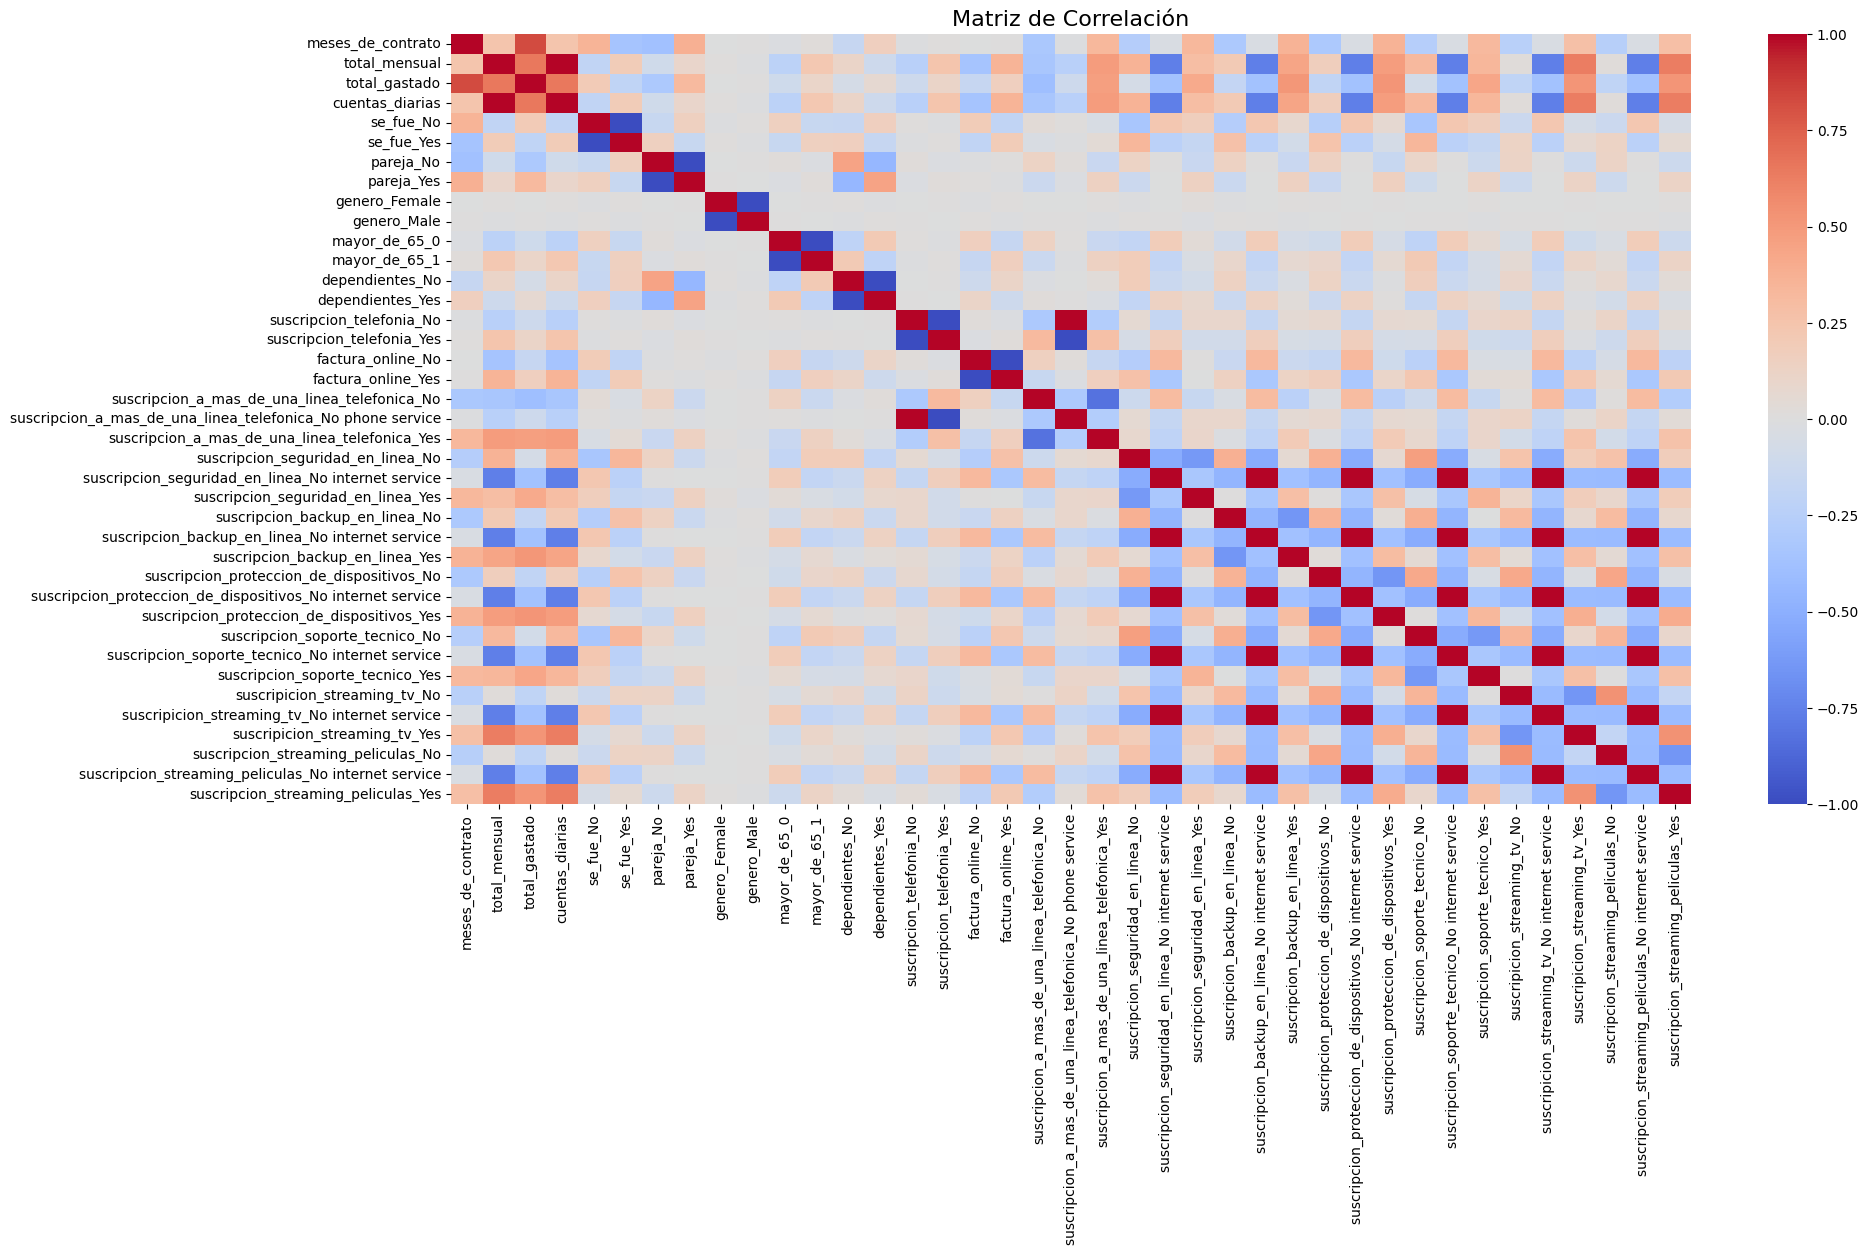

<Figure size 640x480 with 0 Axes>

In [75]:

# Ver correlaciones con churn (se_fue)
corr_churn = corr_matrix['se_fue_Yes'].sort_values(ascending=False)
print(corr_churn)

# Grafico Mapa de Calor
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20,10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación', fontsize=16)
plt.show()

plt.savefig('matriz_correlacion.png')


#📄Informe final

###Introducción:

El presente informe tiene como objetivo analizar el fenómeno de la cancelación de servicios por parte de clientes, comúnmente denominado churn. Este análisis busca identificar patrones y variables asociadas a la cancelación, con el fin de proporcionar recomendaciones que ayuden a reducir la pérdida de clientes.

###Limpieza y Tratamiento de Datos:

*   Se realizó la importación del conjunto de datos original que estaba en api json.
*   Se normalizo los datos que estaban anidados en el json
*   Se cambio los nombes de los campos segun el diccionario de datos proporcionado.
*   Se verifico si hay datos nulos o duplicados.
*   Se visualizo los valores unicon por columnas
*   Se elimino datos vacios
*   Se creao el campo "cuentas_diarias"  calculada a partir del total_mensual.


###Análisis Exploratorio de Datos:

####Distribucion de Abandono
<img src='./imagenes/abandono.png'>

####Tipo de Contrato
<img src='./imagenes/tipo_contrato.png'>

####Meses de Contrato
<img src='./imagenes/meses_contrato_linea.png'>

####Pareja
<img src='./imagenes/pareja.png'>

####Dependientes
<img src='./imagenes/dependientes.png'>

####Mayor de 65
<img src='./imagenes/mayor_65.png'>

####Forma de Pago
<img src='./imagenes/forma_de_pago.png'>

####Tipo de Suscripción a Internet
<img src='./imagenes/suscripcion_internet.png'>

####Factura Online
<img src='./imagenes/factura_online.png'>

####Matriz  de Correlacion
<img src='./imagenes/matriz_de_correlacion.png'>




###Conclusiones e Insights:


*   Los clientes con contrato mensual, fibra óptica y pagos más frecuentes tienen una mayor probabilidad de cancelar el servicio.
*   Los clientes con contrato anual o bianual, pagos automáticos y mayor antigüedad tienden a permanecer más tiempo.
*   El método de pago y el tipo de contrato son factores especialmente influyentes, por que los clientes que usan el pago con cheque electrónico tienen mayor tasa de cancelación.
*   El coste diario y el pago mensual están positivamente correlacionados con la cancelación, lo que sugiere que los clientes con tarifas más altas o percepciones de coste elevado son más propensos a abandonar el servicio.
*   El uso de internet por fibra óptica muestra una mayor asociación con la cancelación, mientras que los clientes con servicio DSL tienden a permanecer más tiempo.
*   Estar adherido a recibir la factura electronica, son mas propensos a abandonar.
*   Los clientes que no tienen pareja, no tienen dependiente, son mas propensos a abandonar, que los clientes que estan en pareja y tienen dependiente.








###Recomendaciones:

Ofrece sugerencias estratégicas basadas en tu análisis.